Auto regressive image captioning task. Uses pretrained resnet model to extract features from the image, beam search for text generation. Explores the following: i) transformer architecture (with teacher_forcing_ratio = 1.0) ii) transformer architecture (with 0.0 < teacher_forcing_ratio < 1.0) iii) bahdanau attention (GRU) iv) Fine tuning CLIP model. <br>
images are at flickr8k/Images/ and captions at flickr8k/captions.txt

In [1]:
import os
import re
import math
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms, io

DATA_ROOT = Path("flickr8k")
IMAGE_DIR = DATA_ROOT / "Images"
CAPTION_FILE = DATA_ROOT / "captions.txt"

BATCH_SIZE = 32 if torch.cuda.is_available() else 4
NUM_WORKERS = 0
MAX_LEN = 32
MIN_FREQ = 2

PAD_ID, BOS_ID, EOS_ID, UNK_ID = 0, 1, 2, 3
D_MODEL = 512
NHEAD = 8
NUM_LAYERS = 4
FF_DIM = 2048
GRU_HIDDEN = 512
ATTN_DIM = 256
DROPOUT = 0.1

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

def normalize_caption(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9']+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def load_flickr8k_captions(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.lower().startswith("image,caption"):
                continue
            m = re.match(r"^(.*?),\d+\s+(.*)$", line)
            if m:
                image, caption = m.group(1).strip(), m.group(2).strip()
            else:
                parts = line.split(",", 1)
                if len(parts) != 2:
                    continue
                image, caption = parts[0].strip(), parts[1].strip()
            rows.append((image, normalize_caption(caption)))
    return pd.DataFrame(rows, columns=["image", "caption"])

class Vocabulary:
    def __init__(self, min_freq=2):
        self.itos = ["<pad>", "<bos>", "<eos>", "<unk>"]
        self.stoi = {t: i for i, t in enumerate(self.itos)}
        self.min_freq = min_freq

    def build(self, texts):
        counts = Counter()
        for text in texts:
            counts.update(text.split())
        for token, freq in sorted(counts.items()):
            if freq >= self.min_freq and token not in self.stoi:
                self.stoi[token] = len(self.itos)
                self.itos.append(token)

    def encode(self, text, max_len=MAX_LEN):
        words = text.split()[:max_len - 2]
        return [BOS_ID] + [self.stoi.get(w, UNK_ID) for w in words] + [EOS_ID]

    def decode(self, ids):
        words = []
        for x in ids:
            x = int(x)
            if x in (PAD_ID, BOS_ID):
                continue
            if x == EOS_ID:
                break
            if 0 <= x < len(self.itos):
                words.append(self.itos[x])
        return " ".join(words)

    def __len__(self):
        return len(self.itos)

captions_df = load_flickr8k_captions(CAPTION_FILE)
images = captions_df["image"].unique().tolist()

rng = np.random.default_rng(42)
rng.shuffle(images)

n = len(images)
n_train = int(0.80 * n)
n_val = int(0.10 * n)

train_images = set(images[:n_train])
val_images = set(images[n_train:n_train + n_val])
test_images = set(images[n_train + n_val:])

train_df = captions_df[captions_df.image.isin(train_images)].reset_index(drop=True)
val_df = captions_df[captions_df.image.isin(val_images)].reset_index(drop=True)
test_df = captions_df[captions_df.image.isin(test_images)].reset_index(drop=True)

vocab = Vocabulary(MIN_FREQ)
vocab.build(train_df.caption)

print("Caption rows:", len(captions_df))
print("Images:", captions_df.image.nunique())
print("Vocab:", len(vocab))
print("Splits:", len(train_images), len(val_images), len(test_images))

image_transform = models.ResNet50_Weights.DEFAULT.transforms()

class FlickrCaptionDataset(Dataset):
    def __init__(self, frame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        path = IMAGE_DIR / row.image
        image = io.read_image(str(path))[:3].float() / 255.0
        image = image_transform(image)
        caption = torch.tensor(vocab.encode(row.caption), dtype=torch.long)
        return {
            "image": image,
            "caption": caption,
            "image_name": row.image,
            "raw_caption": row.caption,
        }

def collate_fn(batch):
    images = torch.stack([x["image"] for x in batch])
    max_len = max(len(x["caption"]) for x in batch)
    captions = torch.full(
        (len(batch), max_len), PAD_ID, dtype=torch.long
    )
    for i, x in enumerate(batch):
        captions[i, :len(x["caption"])] = x["caption"]
    return {
        "images": images,
        "captions": captions,
        "image_names": [x["image_name"] for x in batch],
        "raw_captions": [x["raw_caption"] for x in batch],
    }

train_loader = DataLoader(
    FlickrCaptionDataset(train_df),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
    persistent_workers=(NUM_WORKERS > 0),
)
val_loader = DataLoader(
    FlickrCaptionDataset(val_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
    persistent_workers=(NUM_WORKERS > 0),
)
test_dataset = FlickrCaptionDataset(test_df)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
    persistent_workers=(NUM_WORKERS > 0),
)

DEVICE: cuda
Caption rows: 40455
Images: 8091
Vocab: 4687
Splits: 6472 809 810


In [2]:

# ============================================================
# Pretrained ResNet-50 spatial encoder
# ============================================================
class ResNetImageEncoder(nn.Module):
    def __init__(self, train_backbone=False):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(backbone.children())[:-2])
        self.out_dim = 2048

        if not train_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def forward(self, images):
        x = self.backbone(images)              # [B, 2048, 7, 7]
        return x.flatten(2).transpose(1, 2)   # [B, 49, 2048]

image_encoder = ResNetImageEncoder(False).to(DEVICE)
image_encoder.eval()

batch = next(iter(train_loader))
with torch.no_grad():
    feat = image_encoder(batch["images"].to(DEVICE))
print("Image batch:", tuple(batch["images"].shape))
print("ResNet features:", tuple(feat.shape))
del batch, feat

Image batch: (32, 3, 224, 224)
ResNet features: (32, 49, 2048)


In [3]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).float().unsqueeze(1)
        div = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0), persistent=False)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

def make_causal_mask(T, device):
    return torch.triu(
        torch.ones(T, T, dtype=torch.bool, device=device),
        diagonal=1
    )

In [4]:

# ============================================================
# I. Transformer with teacher_forcing_ratio = 1.0
# ============================================================
class TransformerCaptioner(nn.Module):
    def __init__(
        self,
        vocab_size,
        pad_id,
        image_dim=2048,
        d_model=D_MODEL,
        nhead=NHEAD,
        num_layers=NUM_LAYERS,
        ff_dim=FF_DIM,
        dropout=DROPOUT,
    ):
        super().__init__()
        self.pad_id = pad_id
        self.d_model = d_model

        self.image_proj = nn.Linear(image_dim, d_model)
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos = PositionalEncoding(d_model, MAX_LEN)

        layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.decoder = nn.TransformerDecoder(layer, num_layers)
        self.fc = nn.Linear(d_model, vocab_size)

    def encode_image(self, image_features):
        return self.image_proj(image_features)

    def forward(self, image_features, input_ids):
        memory = self.encode_image(image_features)
        x = self.embedding(input_ids) * math.sqrt(self.d_model)
        x = self.pos(x)

        hidden = self.decoder(
            tgt=x,
            memory=memory,
            tgt_mask=make_causal_mask(x.size(1), x.device),
            tgt_key_padding_mask=input_ids.eq(self.pad_id),
        )
        return self.fc(hidden)

def transformer_tf1_loss(model, features, captions, criterion):
    logits = model(model.encode_image(features) if False else features, captions[:, :-1])
    return criterion(
        logits.reshape(-1, logits.size(-1)),
        captions[:, 1:].reshape(-1)
    )


In [5]:

# ============================================================
# II. Transformer with 0 < teacher_forcing_ratio < 1
# ============================================================
class ScheduledSamplingTransformer(TransformerCaptioner):
    def forward(self, image_features, captions, teacher_forcing_ratio=0.5):
        memory = self.encode_image(image_features)
        current = captions[:, :1]
        outputs = []

        for t in range(1, captions.size(1)):
            x = self.embedding(current) * math.sqrt(self.d_model)
            x = self.pos(x)

            hidden = self.decoder(
                tgt=x,
                memory=memory,
                tgt_mask=make_causal_mask(x.size(1), x.device),
                tgt_key_padding_mask=current.eq(self.pad_id),
            )
            next_logits = self.fc(hidden[:, -1])
            outputs.append(next_logits)

            if t == captions.size(1) - 1:
                break

            if random.random() < teacher_forcing_ratio:
                next_token = captions[:, t:t + 1]
            else:
                next_token = next_logits.argmax(-1, keepdim=True)

            current = torch.cat([current, next_token], dim=1)

        return torch.stack(outputs, dim=1)

def scheduled_sampling_loss(model, features, captions, criterion, tf_ratio):
    logits = model(features, captions, tf_ratio)
    return criterion(
        logits.reshape(-1, logits.size(-1)),
        captions[:, 1:].reshape(-1)
    )


In [6]:
EMBED_DIM=256
# ============================================================
# III. Bahdanau attention + GRU
# ============================================================
class BahdanauAttention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.enc = nn.Linear(encoder_dim, attention_dim, bias=False)
        self.dec = nn.Linear(decoder_dim, attention_dim, bias=False)
        self.v = nn.Linear(attention_dim, 1, bias=False)

    def forward(self, features, hidden):
        energy = torch.tanh(
            self.enc(features) + self.dec(hidden).unsqueeze(1)
        )
        scores = self.v(energy).squeeze(-1)
        weights = F.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), features).squeeze(1)
        return context, weights

class BahdanauGRUCaptioner(nn.Module):
    def __init__(
        self,
        vocab_size,
        pad_id,
        image_dim=2048,
        embed_dim=EMBED_DIM,
        hidden_dim=GRU_HIDDEN,
        attention_dim=ATTN_DIM,
        dropout=DROPOUT,
    ):
        super().__init__()
        self.pad_id = pad_id
        self.hidden_dim = hidden_dim

        self.image_proj = nn.Linear(image_dim, hidden_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.attention = BahdanauAttention(hidden_dim, hidden_dim, attention_dim)
        self.gru = nn.GRU(embed_dim + hidden_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim + hidden_dim, vocab_size)

    def init_hidden(self, image_features):
        pooled = image_features.mean(dim=1)
        return torch.tanh(self.image_proj(pooled)).unsqueeze(0)

    def forward(
        self,
        image_features,
        captions,
        teacher_forcing_ratio=1.0,
        return_attention=False,
    ):
        features = self.image_proj(image_features)
        hidden = self.init_hidden(image_features)
        token = captions[:, 0]

        outputs, attention_history = [], []

        for t in range(1, captions.size(1)):
            context, weights = self.attention(features, hidden[-1])
            emb = self.embedding(token)
            gru_in = torch.cat([emb, context], dim=-1).unsqueeze(1)

            out, hidden = self.gru(gru_in, hidden)
            out = out.squeeze(1)

            logits = self.fc(
                torch.cat([self.dropout(out), context], dim=-1)
            )
            outputs.append(logits)

            if return_attention:
                attention_history.append(weights)

            if t == captions.size(1) - 1:
                break

            if random.random() < teacher_forcing_ratio:
                token = captions[:, t]
            else:
                token = logits.argmax(-1)

        logits = torch.stack(outputs, dim=1)

        if return_attention:
            return logits, torch.stack(attention_history, dim=1)
        return logits

def gru_loss(model, features, captions, criterion, tf_ratio=1.0):
    logits = model(features, captions, tf_ratio)
    return criterion(
        logits.reshape(-1, logits.size(-1)),
        captions[:, 1:].reshape(-1)
    )


In [7]:
from tqdm import tqdm
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

def run_epoch(
    decoder,
    loader,
    model_type,
    optimizer=None,
    tf_ratio=1.0,
):
    training = optimizer is not None
    decoder.train(training)
    image_encoder.eval()

    total_loss = 0.0
    total_tokens = 0

    for batch in tqdm(loader, desc=f"{'training' if training else 'validation'}"):
        images = batch["images"].to(DEVICE, non_blocking=True)
        captions = batch["captions"].to(DEVICE, non_blocking=True)

        with torch.no_grad():
            features = image_encoder(images)

        if training:
            optimizer.zero_grad(set_to_none=True)

        if model_type == "tf1":
            loss = transformer_tf1_loss(
                decoder, features, captions, criterion
            )
        elif model_type == "scheduled":
            loss = scheduled_sampling_loss(
                decoder, features, captions, criterion, tf_ratio
            )
        elif model_type == "gru":
            loss = gru_loss(
                decoder, features, captions, criterion, tf_ratio
            )
        else:
            raise ValueError(model_type)

        if training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(decoder.parameters(), 1.0)
            optimizer.step()

        n = captions[:, 1:].ne(PAD_ID).sum().item()
        total_loss += loss.item() * n
        total_tokens += n

    return total_loss / max(total_tokens, 1)

def fit_model(
    decoder,
    model_type,
    epochs=5,
    lr=3e-4,
    tf_schedule=None,
):
    optimizer = torch.optim.AdamW(
        decoder.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    history = {"train": [], "val": [], "tf": []}
    best_val = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        tf = 1.0 if tf_schedule is None else tf_schedule(epoch, epochs)

        train_loss = run_epoch(
            decoder, train_loader, model_type,
            optimizer=optimizer, tf_ratio=tf
        )
        val_loss = run_epoch(
            decoder, val_loader, model_type,
            optimizer=None, tf_ratio=1.0
        )

        history["train"].append(train_loss)
        history["val"].append(val_loss)
        history["tf"].append(tf)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in decoder.state_dict().items()
            }

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"TF={tf:.3f} | train={train_loss:.4f} | val={val_loss:.4f}"
        )

    if best_state is not None:
        decoder.load_state_dict(best_state)

    return optimizer, history

def plot_history(history, title):
    plt.figure(figsize=(7, 4))
    plt.plot(history["train"], label="train")
    plt.plot(history["val"], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("Cross entropy")
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()


In [8]:

# ============================================================
# Beam search
# ============================================================
@torch.no_grad()
def beam_search_transformer(
    model,
    features,
    beam_size=5,
    max_len=MAX_LEN,
    length_penalty=0.7,
):
    model.eval()
    memory = model.encode_image(features)
    device = features.device

    beams = [([BOS_ID], 0.0)]
    finished = []

    for _ in range(max_len - 1):
        candidates = []

        for seq, score in beams:
            if seq[-1] == EOS_ID:
                finished.append((seq, score))
                continue

            ids = torch.tensor(seq, dtype=torch.long, device=device).unsqueeze(0)
            x = model.embedding(ids) * math.sqrt(model.d_model)
            x = model.pos(x)

            hidden = model.decoder(
                tgt=x,
                memory=memory,
                tgt_mask=make_causal_mask(len(seq), device),
                tgt_key_padding_mask=ids.eq(model.pad_id),
            )

            logp = F.log_softmax(model.fc(hidden[:, -1]), dim=-1)
            vals, idxs = torch.topk(logp, beam_size, dim=-1)

            for j in range(beam_size):
                candidates.append(
                    (
                        seq + [int(idxs[0, j])],
                        score + float(vals[0, j]),
                    )
                )

        if not candidates:
            break

        candidates.sort(key=lambda x: x[1], reverse=True)
        beams = candidates[:beam_size]

        if all(seq[-1] == EOS_ID for seq, _ in beams):
            break

    finished.extend(beams)

    def normalized(item):
        seq, score = item
        length = max(1, len(seq) - 1)
        return score / (length ** length_penalty)

    return max(finished, key=normalized)[0]

@torch.no_grad()
def beam_search_gru(
    model,
    features,
    beam_size=5,
    max_len=MAX_LEN,
    length_penalty=0.7,
):
    model.eval()

    encoded = model.image_proj(features)
    hidden0 = model.init_hidden(features)
    device = features.device

    beams = [([BOS_ID], 0.0, hidden0)]
    finished = []

    for _ in range(max_len - 1):
        candidates = []

        for seq, score, hidden in beams:
            if seq[-1] == EOS_ID:
                finished.append((seq, score))
                continue

            token = torch.tensor([seq[-1]], dtype=torch.long, device=device)

            context, _ = model.attention(encoded, hidden[-1])
            emb = model.embedding(token)
            gru_in = torch.cat([emb, context], dim=-1).unsqueeze(1)

            out, next_hidden = model.gru(gru_in, hidden)
            out = out.squeeze(1)

            logits = model.fc(torch.cat([out, context], dim=-1))
            logp = F.log_softmax(logits, dim=-1)
            vals, idxs = torch.topk(logp, beam_size, dim=-1)

            for j in range(beam_size):
                candidates.append(
                    (
                        seq + [int(idxs[0, j])],
                        score + float(vals[0, j]),
                        next_hidden.detach().clone(),
                    )
                )

        if not candidates:
            break

        candidates.sort(key=lambda x: x[1], reverse=True)
        beams = candidates[:beam_size]

        if all(seq[-1] == EOS_ID for seq, _, _ in beams):
            break

    finished.extend((seq, score) for seq, score, _ in beams)

    def normalized(item):
        seq, score = item
        length = max(1, len(seq) - 1)
        return score / (length ** length_penalty)

    return max(finished, key=normalized)[0]


In [9]:

# ============================================================
# Inference + visualization
# ============================================================
@torch.no_grad()
def generate_caption(dataset, index, decoder, decoder_type, beam_size=5):
    item = dataset[index]
    image = item["image"].unsqueeze(0).to(DEVICE)

    image_encoder.eval()
    decoder.eval()

    features = image_encoder(image)

    if decoder_type in ("tf1", "scheduled"):
        ids = beam_search_transformer(
            decoder, features, beam_size=beam_size
        )
    elif decoder_type == "gru":
        ids = beam_search_gru(
            decoder, features, beam_size=beam_size
        )
    else:
        raise ValueError(decoder_type)

    return vocab.decode(ids), ids, item

def show_prediction(dataset, index, decoder, decoder_type, beam_size=5):
    caption, ids, item = generate_caption(
        dataset, index, decoder, decoder_type, beam_size
    )

    image = io.read_image(
        str(IMAGE_DIR / item["image_name"])
    ).permute(1, 2, 0)

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Prediction: {caption}\nReference: {item['raw_caption']}"
    )
    plt.show()

    print("Prediction:", caption)
    print("Reference :", item["raw_caption"])
    print("IDs       :", ids)


validation: 100%|██████████| 127/127 [00:29<00:00,  4.25it/s]


Epoch 01/5 | TF=1.000 | train=8.3541 | val=5.7178


validation: 100%|██████████| 127/127 [00:21<00:00,  5.80it/s]


Epoch 02/5 | TF=1.000 | train=4.9377 | val=5.3540


validation: 100%|██████████| 127/127 [00:21<00:00,  5.80it/s]


Epoch 03/5 | TF=1.000 | train=4.1241 | val=4.9948


validation: 100%|██████████| 127/127 [00:21<00:00,  5.80it/s]


Epoch 04/5 | TF=1.000 | train=3.5204 | val=4.8545


validation: 100%|██████████| 127/127 [00:21<00:00,  5.82it/s]


Epoch 05/5 | TF=1.000 | train=3.0519 | val=4.8844


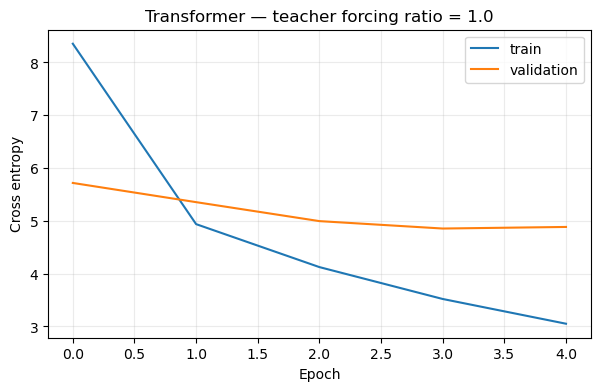

In [10]:

# ============================================================
# TRAIN I — Transformer, teacher forcing = 1.0
# ============================================================
transformer_tf1 = TransformerCaptioner(
    vocab_size=len(vocab),
    pad_id=PAD_ID,
).to(DEVICE)

optimizer_tf1, history_tf1 = fit_model(
    transformer_tf1,
    model_type="tf1",
    epochs=5,
    lr=3e-4,
)

plot_history(
    history_tf1,
    "Transformer — teacher forcing ratio = 1.0"
)

# Example after training:
# show_prediction(test_dataset, 0, transformer_tf1, "tf1", beam_size=5)


In [11]:

# ============================================================
# TRAIN II — Transformer with 0 < teacher_forcing_ratio < 1
# ============================================================
def scheduled_tf(epoch, total_epochs):
    if total_epochs == 1:
        return 0.5
    return max(
        0.2,
        1.0 - 0.8 * (epoch - 1) / (total_epochs - 1)
    )

transformer_scheduled = ScheduledSamplingTransformer(
    vocab_size=len(vocab),
    pad_id=PAD_ID,
).to(DEVICE)

optimizer_sched, history_sched = fit_model(
    transformer_scheduled,
    model_type="scheduled",
    epochs=5,
    lr=3e-4,
    tf_schedule=scheduled_tf,
)

plot_history(
    history_sched,
    "Transformer — scheduled sampling"
)

# Example after training:
# show_prediction(test_dataset, 0, transformer_scheduled, "scheduled", beam_size=5)


validation: 100%|██████████| 127/127 [00:40<00:00,  3.17it/s]


Epoch 01/5 | TF=1.000 | train=8.3526 | val=5.8449


training:   4%|▎         | 37/1012 [00:21<09:36,  1.69it/s]


KeyboardInterrupt: 

In [12]:

# ============================================================
# TRAIN III — Bahdanau attention + GRU
# ============================================================
gru_captioner = BahdanauGRUCaptioner(
    vocab_size=len(vocab),
    pad_id=PAD_ID,
).to(DEVICE)

optimizer_gru, history_gru = fit_model(
    gru_captioner,
    model_type="gru",
    epochs=5,
    lr=3e-4,
    tf_schedule=scheduled_tf,
)

plot_history(
    history_gru,
    "Bahdanau attention + GRU"
)

# Example after training:
# show_prediction(test_dataset, 0, gru_captioner, "gru", beam_size=5)


validation: 100%|██████████| 127/127 [00:21<00:00,  5.83it/s]


Epoch 01/5 | TF=1.000 | train=3.5571 | val=3.0207


training:   4%|▍         | 41/1012 [00:08<03:28,  4.67it/s]


KeyboardInterrupt: 

training speed: transformer (tf = 1) > GRU > transformer (tf < 1)

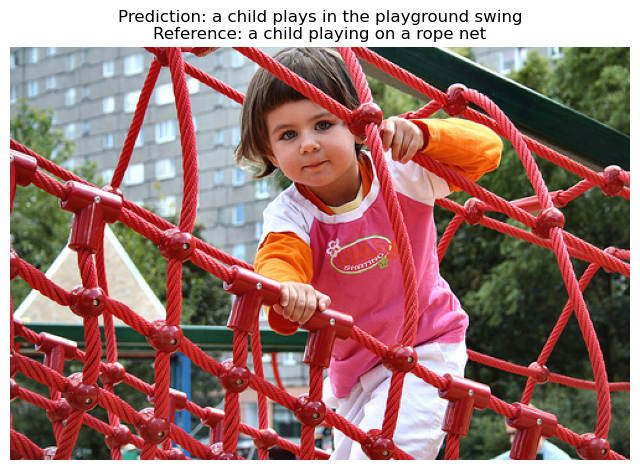

Prediction: a child plays in the playground swing
Reference : a child playing on a rope net
IDs       : [1, 25, 791, 2977, 2040, 4164, 2973, 4075, 2]


In [13]:
show_prediction(test_dataset, 0, transformer_tf1, "tf1", beam_size=5)

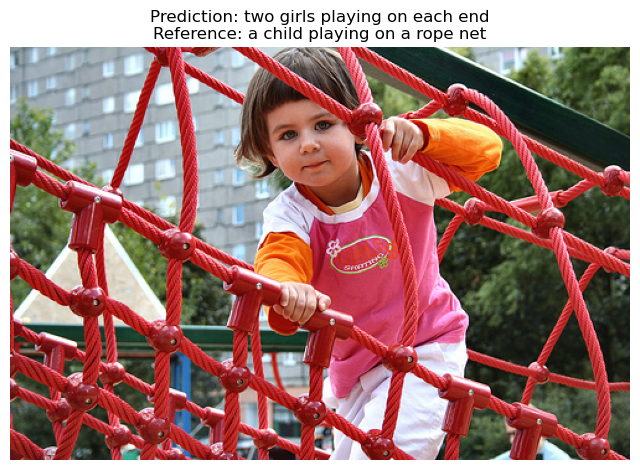

Prediction: two girls playing on each end
Reference : a child playing on a rope net
IDs       : [1, 4376, 1710, 2975, 2691, 1307, 1358, 2]


In [14]:
show_prediction(test_dataset, 0, transformer_scheduled, "scheduled", beam_size=5)

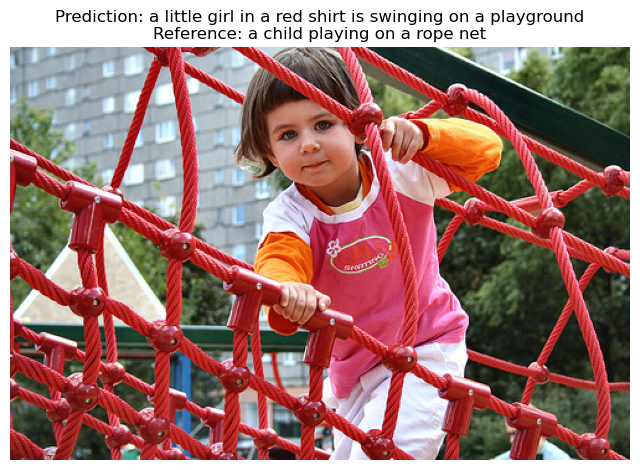

Prediction: a little girl in a red shirt is swinging on a playground
Reference : a child playing on a rope net
IDs       : [1, 25, 2327, 1709, 2040, 25, 3234, 3550, 2092, 4076, 2691, 25, 2973, 2]


In [15]:
show_prediction(test_dataset, 0, gru_captioner, "gru", beam_size=5)

In [16]:
torch.save(transformer_tf1.state_dict(), "transformer_tf1_ckpt.pt")
torch.save(transformer_scheduled.state_dict(), "transformer_sch_ckpt.pt")
torch.save(gru_captioner.state_dict(), "gru_ckpt.pt")
print("saved")

saved


In [ ]:

# ============================================================
# Bahdanau attention visualization
# ============================================================
@torch.no_grad()
def get_gru_attention(model, dataset, index):
    item = dataset[index]
    ids = vocab.encode(item["raw_caption"])

    image = item["image"].unsqueeze(0).to(DEVICE)
    features = image_encoder(image)

    _, attention = model(
        features,
        torch.tensor([ids], dtype=torch.long, device=DEVICE),
        teacher_forcing_ratio=1.0,
        return_attention=True,
    )
    return item, ids, attention[0].cpu()

def plot_attention_step(item, ids, attention, step):
    step = min(step, attention.shape[0] - 1)
    words = ["<bos>"] + item["raw_caption"].split()[:len(ids) - 2] + ["<eos>"]

    grid = attention[step].reshape(7, 7).numpy()

    plt.figure(figsize=(6, 6))
    plt.imshow(
        io.read_image(
            str(IMAGE_DIR / item["image_name"])
        ).permute(1, 2, 0)
    )
    plt.imshow(
        grid,
        cmap="jet",
        alpha=0.35,
        extent=(0, 224, 224, 0)
    )
    plt.axis("off")
    plt.title(f"Attention for token: {words[step + 1]}")
    plt.show()

# Example:
# item, ids, attention = get_gru_attention(gru_captioner, test_dataset, 0)
# plot_attention_step(item, ids, attention, step=3)


In [ ]:

# ============================================================
# Optional BLEU evaluation
# ============================================================
def evaluate_bleu(model, dataset, decoder_type, max_items=200, beam_size=3):
    try:
        from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
    except ImportError as e:
        raise ImportError(
            "Install nltk first with: pip install nltk"
        ) from e

    references = []
    hypotheses = []

    n = min(max_items, len(dataset))

    for i in range(n):
        prediction, _, item = generate_caption(
            dataset, i, model, decoder_type, beam_size
        )

        refs = [
            c.split()
            for c in captions_df.loc[
                captions_df.image == item["image_name"], "caption"
            ].tolist()
        ]

        references.append(refs)
        hypotheses.append(prediction.split())

    smooth = SmoothingFunction().method3

    bleu1 = corpus_bleu(
        references,
        hypotheses,
        weights=(1, 0, 0, 0),
        smoothing_function=smooth
    )
    bleu4 = corpus_bleu(
        references,
        hypotheses,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )

    return {"BLEU-1": bleu1, "BLEU-4": bleu4}

# Examples:
# print(evaluate_bleu(transformer_tf1, test_dataset, "tf1"))
# print(evaluate_bleu(transformer_scheduled, test_dataset, "scheduled"))
# print(evaluate_bleu(gru_captioner, test_dataset, "gru"))


## Optional CLIP extension

The original notebook description also mentions fine-tuning CLIP. The natural integration is:

`image -> CLIP vision encoder -> patch tokens -> Transformer caption decoder`

Start with the CLIP vision encoder frozen. After the captioning pipeline is working, unfreeze selected vision layers with a smaller learning rate than the decoder.

In [ ]:

# ============================================================
# OPTIONAL: CLIP vision encoder
# ============================================================
try:
    from transformers import CLIPVisionModel
    TRANSFORMERS_AVAILABLE = True
except ImportError:
    TRANSFORMERS_AVAILABLE = False
    print("transformers is not installed; skipping CLIP setup.")

if TRANSFORMERS_AVAILABLE:
    CLIP_NAME = "openai/clip-vit-base-patch32"

    clip_model = CLIPVisionModel.from_pretrained(CLIP_NAME).to(DEVICE)

    for p in clip_model.parameters():
        p.requires_grad = False

    clip_model.eval()

    class CLIPImageEncoder(nn.Module):
        def __init__(self, vision_model):
            super().__init__()
            self.model = vision_model
            self.out_dim = vision_model.config.hidden_size

        def forward(self, pixel_values):
            hidden = self.model(pixel_values=pixel_values).last_hidden_state
            return hidden[:, 1:, :]  # remove CLS

    clip_encoder = CLIPImageEncoder(clip_model)

    print("CLIP feature dimension:", clip_encoder.out_dim)
    print("CLIP encoder is frozen.")


In [ ]:

# ============================================================
# Checkpoints
# ============================================================
def save_checkpoint(path, model, optimizer=None, history=None):
    torch.save(
        {
            "model": model.state_dict(),
            "optimizer": None if optimizer is None else optimizer.state_dict(),
            "history": history,
            "vocab_itos": vocab.itos,
        },
        path,
    )
    print("Saved:", path)

def load_checkpoint(path, model, optimizer=None):
    state = torch.load(path, map_location=DEVICE)
    model.load_state_dict(state["model"])

    if optimizer is not None and state["optimizer"] is not None:
        optimizer.load_state_dict(state["optimizer"])

    return state

# Examples:
# save_checkpoint("transformer_tf1.pt", transformer_tf1, optimizer_tf1, history_tf1)
# save_checkpoint("transformer_scheduled.pt", transformer_scheduled, optimizer_sched, history_sched)
# save_checkpoint("gru_attention.pt", gru_captioner, optimizer_gru, history_gru)
